<a href="https://colab.research.google.com/github/princealexanderm/-ICT_AI_ML/blob/main/ICT_AI_ML_Internship_Sep_Oct_2025.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

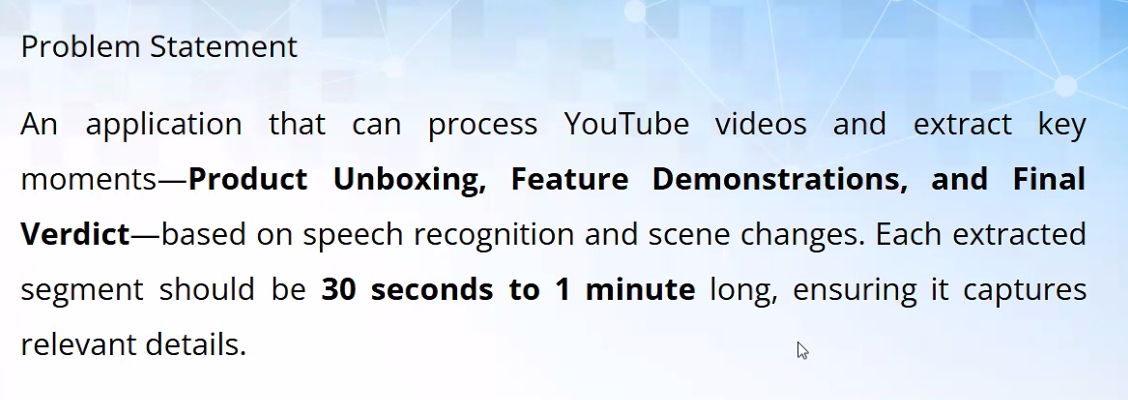

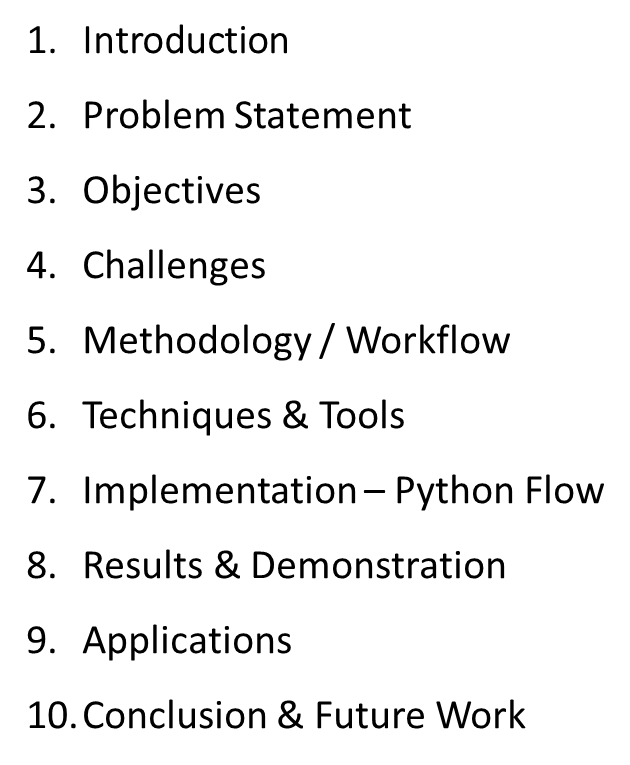

In [ ]:
# video_highlight_extractor.py
import os, subprocess, math, shutil
from pathlib import Path
import numpy as np
import yt_dlp
import ffmpeg
import whisper
import librosa
from scenedetect import VideoManager, SceneManager
from scenedetect.detectors import ContentDetector
from ultralytics import YOLO
from transformers import pipeline

# ---------------- config ----------------
VIDEO_DIR = Path("videos")
AUDIO_DIR = Path("audio")
OUTPUT_DIR = Path("clips")
VIDEO_DIR.mkdir(exist_ok=True)
AUDIO_DIR.mkdir(exist_ok=True)
OUTPUT_DIR.mkdir(exist_ok=True)

WHISPER_MODEL = "small"      # small/base/medium for speed/accuracy tradeoff
YOLO_MODEL = "yolov8n.pt"    # small YOLO for speed
CLIP_MIN = 30.0              # seconds (min clip length)
CLIP_MAX = 60.0              # seconds (max clip length)
SAMPLE_FPS = 1               # how many frames/sec to run object detection on (low for speed)

# keywords to categorize segments
KEYWORDS = {
    "unboxing": ["unbox", "box", "open the box", "take out", "out of the box"],
    "feature": ["feature", "spec", "battery", "camera", "display", "performance", "fps", "zoom"],
    "verdict": ["final", "verdict", "recommend", "don't buy", "buy", "overall", "conclusion", "impression"]
}

# ---------------- helpers ----------------
def download_youtube(url, outdir=VIDEO_DIR):
    ydl_opts = {
        "format": "bestvideo+bestaudio/best",
        "outtmpl": str(outdir / "%(id)s.%(ext)s"),
        "merge_output_format": "mp4",
        "noplaylist": True,
        "writesubtitles": False
    }
    with yt_dlp.YoutubeDL(ydl_opts) as ydl:
        info = ydl.extract_info(url, download=True)
        filename = ydl.prepare_filename(info)
        # ensure mp4 extension
        if not filename.endswith(".mp4"):
            base = os.path.splitext(filename)[0]
            filename = base + ".mp4"
        return str(Path(filename).resolve()), info

def extract_audio(video_path, out_audio_path):
    # Use ffmpeg to create a mono 16k WAV for ASR
    (
        ffmpeg
        .input(video_path)
        .output(out_audio_path, ac=1, ar=16000, format='wav')
        .overwrite_output()
        .run(quiet=True)
    )
    return out_audio_path

def transcribe_with_whisper(audio_path, model_name=WHISPER_MODEL):
    model = whisper.load_model(model_name)
    # returns dict with 'segments' list of {start, end, text}
    result = model.transcribe(audio_path, verbose=False)
    segments = result.get("segments", [])
    return segments

def detect_scenes(video_path):
    video_manager = VideoManager([video_path])
    scene_manager = SceneManager()
    scene_manager.add_detector(ContentDetector(threshold=27.0))  # tune threshold
    base_timecode = video_manager.get_base_timecode()
    video_manager.start()
    scene_manager.detect_scenes(frame_source=video_manager)
    scene_list = scene_manager.get_scene_list(base_timecode)
    # convert to times (seconds) list of boundaries
    boundaries = [0.0]
    for start, end in scene_list:
        boundaries.append(start.get_seconds())
    # add final
    try:
        duration = float(ffmpeg.probe(video_path)['format']['duration'])
    except:
        duration = boundaries[-1]
    boundaries = sorted(set(boundaries + [duration]))
    video_manager.release()
    return boundaries

def sample_frames_for_detection(video_path, fps=SAMPLE_FPS, tmp_dir=Path("tmp_frames")):
    tmp_dir.mkdir(exist_ok=True)
    # extract frames at 1 fps: ffmpeg -i video -vf fps=1 frame_%06d.jpg
    frame_pattern = str(tmp_dir / "frame_%06d.jpg")
    (
        ffmpeg
        .input(video_path)
        .filter('fps', fps)
        .output(frame_pattern, **{'qscale:v': 2})
        .overwrite_output()
        .run(quiet=True)
    )
    frames = sorted(tmp_dir.glob("frame_*.jpg"))
    return frames

def detect_objects_on_frames(frame_paths, model_path=YOLO_MODEL, classes=None, conf=0.3):
    # classes can be list of class names to match, else returns all labels
    model = YOLO(model_path)
    detections = {}
    for fp in frame_paths:
        res = model.predict(source=str(fp), imgsz=640, conf=conf, verbose=False)
        # res is list per image - take first
        r = res[0]
        objs = []
        for box in r.boxes:
            cls = int(box.cls.cpu().numpy()[0])
            label = model.names.get(cls, str(cls))
            objs.append(label)
        detections[str(fp)] = objs
    return detections

def audio_energy_timeline(audio_path, hop_length=1024):
    y, sr = librosa.load(audio_path, sr=None)
    # short-time energy
    frame_energy = np.array([
        np.sum(np.abs(y[i:i+hop_length])**2)
        for i in range(0, len(y), hop_length)
    ])
    # convert frame index -> time
    times = np.arange(len(frame_energy)) * (hop_length / sr)
    return times, frame_energy

def find_keyword_segments(segments):
    """
    segments: whisper segments (start,end,text)
    return: list of (start, end, label, score, text)
    """
    hits = []
    for seg in segments:
        text = seg["text"].lower()
        start, end = seg["start"], seg["end"]
        for label, kwlist in KEYWORDS.items():
            for kw in kwlist:
                if kw in text:
                    hits.append({"start": start, "end": end, "label": label, "text": seg["text"], "kw": kw})
    return hits

def sentiment_score_for_segment(text):
    # lightweight sentiment check (positive/negative) for verdict-like lines
    classifier = pipeline("sentiment-analysis", model="distilbert-base-uncased-finetuned-sst-2-english")
    r = classifier(text[:512])  # limit length
    # r is list like [{'label': 'POSITIVE', 'score': 0.99}]
    return r[0]

def make_candidate_clips(hits, scene_boundaries, duration, min_len=CLIP_MIN, max_len=CLIP_MAX):
    """
    hits: list of {'start','end','label',...}
    returns candidate list with start,end,label,score placeholders
    """
    candidates = []
    for h in hits:
        center = (h["start"] + h["end"]) / 2.0
        # default target length
        L = min_len
        # if the event is longer than min_len, use its length bounded by max_len
        event_len = h["end"] - h["start"]
        if event_len > L:
            L = min(event_len * 1.5, max_len)
        start = max(0.0, center - L/2)
        end = min(duration, start + L)
        # adjust start if near end
        start = max(0.0, end - L)
        candidates.append({"start": start, "end": end, "label": h["label"], "text": h.get("text","")})
    # merge overlapped candidates
    candidates_sorted = sorted(candidates, key=lambda x: x["start"])
    merged = []
    for c in candidates_sorted:
        if not merged:
            merged.append(c)
        else:
            last = merged[-1]
            # if overlap or adjacent within 3s => merge and extend
            if c["start"] <= last["end"] + 3.0:
                last["end"] = max(last["end"], c["end"])
                last["label"] = last["label"] + "+" + c["label"]
                last["text"] = (last["text"] + " " + c["text"]).strip()
            else:
                merged.append(c)
    # enforce length bounds
    for m in merged:
        L = m["end"] - m["start"]
        if L < min_len:
            extra = min_len - L
            m["start"] = max(0.0, m["start"] - extra/2)
            m["end"] = min(duration, m["end"] + extra/2)
    return merged

def score_candidates(candidates, object_detections, energy_times, energy_values, transcript_texts):
    # very simple scoring function:
    scored = []
    for c in candidates:
        score = 0.0
        # +2 for containing 'verdict' label
        if "verdict" in c["label"]:
            score += 3.0
        if "unboxing" in c["label"]:
            score += 2.0
        if "feature" in c["label"]:
            score += 1.5
        # text length adds small score
        if len(c.get("text",""))>20:
            score += 0.5
        # object presence: check frames near center
        center = (c["start"] + c["end"])/2
        # find nearest frame file (frame times approx)
        # cheap check: see if any detected frame filename contains center time (if naming encodes time) OR simply count all detections (this is example)
        # add small score if any object detections present
        any_obj = any(len(objs)>0 for objs in object_detections.values())
        if any_obj:
            score += 1.0
        # audio energy: add score if there's a local energy peak inside the clip
        idxs = np.where((energy_times>=c["start"]) & (energy_times<=c["end"]))[0]
        if idxs.size>0:
            local_energy = energy_values[idxs].mean()
            if local_energy > np.median(energy_values) * 2.0:
                score += 1.0
        scored.append({**c, "score": score})
    # sort highest first
    scored_sorted = sorted(scored, key=lambda x: x["score"], reverse=True)
    return scored_sorted

def extract_clip_with_ffmpeg(video_path, start, end, out_path):
    duration = end - start
    # re-encode to avoid keyframe start issues
    (
        ffmpeg
        .input(video_path, ss=start, t=duration)
        .output(out_path, vcodec='libx264', acodec='aac', strict='experimental')
        .overwrite_output()
        .run(quiet=True)
    )

# ---------------- main orchestration ----------------
def process_youtube_for_highlights(youtube_url, top_k=3):
    print("Downloading...")
    video_path, info = download_youtube(youtube_url)
    print("Video:", video_path)
    duration = float(ffmpeg.probe(video_path)['format']['duration'])

    # extract audio
    audio_path = AUDIO_DIR / (Path(video_path).stem + ".wav")
    extract_audio(video_path, str(audio_path))

    # speech --> segments
    print("Transcribing (Whisper)...")
    segments = transcribe_with_whisper(str(audio_path))
    print("Transcribed segments:", len(segments))

    # find keyword hits
    hits = find_keyword_segments(segments)
    print("Keyword hits:", len(hits))

    # scene detection
    print("Detecting scenes...")
    scene_boundaries = detect_scenes(video_path)
    print("Scene boundaries:", len(scene_boundaries))

    # sample frames and detect objects (lightweight)
    print("Sampling frames for object detection...")
    frames = sample_frames_for_detection(video_path, fps=SAMPLE_FPS)
    print("Frames extracted:", len(frames))
    print("Running object detection on sampled frames (this may be slow)...")
    obj_dets = detect_objects_on_frames(frames)

    # audio energy timeline
    print("Computing audio energy...")
    energy_times, energy_values = audio_energy_timeline(str(audio_path))

    # candidate clips
    print("Building candidates...")
    candidates = make_candidate_clips(hits, scene_boundaries, duration)
    print("Raw candidates:", len(candidates))

    # scoring
    print("Scoring candidates...")
    scored = score_candidates(candidates, obj_dets, energy_times, energy_values, segments)

    # take top_k and extract
    out_clips = []
    for i, c in enumerate(scored[:top_k]):
        out_name = OUTPUT_DIR / f"{Path(video_path).stem}_clip_{i+1}_{c['label'][:12].replace(' ','_')}.mp4"
        print(f"Extracting clip {i+1}: {c['start']:.2f} -> {c['end']:.2f} score={c['score']:.2f} label={c['label']}")
        extract_clip_with_ffmpeg(video_path, c['start'], c['end'], str(out_name))
        out_clips.append(str(out_name))

    print("Done. Clips saved:", out_clips)
    return out_clips

# -------------- example run --------------
if __name__ == "__main__":
    url = input("Enter YouTube URL: ").strip()
    process_youtube_for_highlights(url, top_k=4)
